# O que é Convolução?
## Uma visão intuitiva

@author: Wallisson Policarpo Teodoro, 2025-2

A convolução é uma operação matemática que combina duas funções (ou sinais) para produzir uma terceira, expressando como a forma de uma é modificada pela outra. É uma das ferramentas mais importantes em engenharia e ciência da computação.

Pense nela como uma forma de "misturar" ou "aplicar um efeito". Temos um **sinal de entrada** ($x$) e um **filtro** ou **efeito** ($h$). A convolução ($y$) nos diz qual é a saída.

Existem duas formas principais que vamos explorar:

## 1. Convolução contínua
É a base teórica, definida pela **Integral da Convolução**. Ela se aplica a sinais definidos em domínios contínuos, como o tempo. A intuição visual clássica é a de **"inverter e deslizar"** uma função sobre a outra e calcular a área de sobreposição a cada instante. É o fundamento matemático por trás do fenômeno.

$$
\Large
y(t) = x(t) * h(t) = \int_{-\infty}^{\infty} x(\tau) \cdot h(t - \tau) d\tau
$$


## 2. Convolução discreta
É a versão para o mundo digital, onde os sinais são sequências de números (vetores para áudio, matrizes para imagens). Em vez de uma integral, usamos um **somatório**. A intuição aqui é a de uma **"janela deslizante com um filtro"**:

1.  **Filtro (ou Kernel):** Uma pequena matriz de pesos que define a característica que queremos extrair (ex: bordas, desfoque).
2.  **Janela Deslizante:** O filtro desliza sobre todos os pontos do dado de entrada.
3.  **Operação:** Em cada posição, multiplicamos os elementos do filtro pelos elementos do sinal sob ele e somamos tudo, gerando um único valor na saída.

$$
\Large
y[n] = x[n] * h[n] = \sum_{k=-\infty}^{\infty} x[k] \cdot h[n - k]
$$

**Nesta apresentação, vamos explorar essa poderosa ferramenta, começando pela intuição visual da convolução contínua e, em seguida, mergulhando nas aplicações práticas da convolução discreta em vetores (áudio) e matrizes (imagens).**


## 3. Convolução contínua: A base teórica
O processo visual para calcular o resultado $y(t)$ para um $t$ específico é:

1.  **Inverter (Flip):** Pegamos a função $h(\tau)$ e a invertemos em relação ao eixo vertical, obtendo $h(-\tau)$.
2.  **Deslizar (Slide):** Deslocamos a função invertida por uma quantidade $t$, resultando em $h(t - \tau)$. Esta é a função que "desliza".
3.  **Multiplicar e Integrar:** Para cada instante $t$, multiplicamos ponto a ponto a função original $x(\tau)$ pela função deslizando $h(t - \tau)$. O resultado da convolução, $y(t)$, é a **área sob a curva** desse produto.

Vamos visualizar isso de forma interativa!


In [1]:
%load_ext autoreload
%autoreload 2
import sys
# Raiz do repositório (assets-main) fica dois níveis acima da pasta deste notebook
if '../../' not in sys.path:
    sys.path.append('../../')
from lib.myPlotLib import *

In [2]:
# Importando as bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# Definindo dois sinais simples (pulsos retangulares)
def x(t):
    '''
    Sinal de entrada: um pulso retangular de t=0 a t=3
    '''
    return np.where((t >= 0) & (t <= 3), 1.0, 0.0)

def h(t):
    '''
    Resposta ao impulso: um pulso retangular mais curto, de t=0 a t=1.5
    '''
    return np.where((t >= 0) & (t <= 1.5), 0.8, 0.0) # Amplitude 0.8 para diferenciar

# Eixo de tempo para cálculo e plotagem
tau = np.linspace(-5, 10, 1000)
t_range = np.linspace(-2, 7, 200)

# Pré-calculando o resultado completo da convolução para o gráfico de baixo
# Usamos np.convolve no modo 'full' para obter o resultado completo
# dt é o passo de tempo, necessário para aproximar a integral
dt = tau[1] - tau[0]
y_completo = dt * np.convolve(x(tau), h(tau), mode='full')
# Ajustando o eixo de tempo para o resultado da convolução
t_y = np.linspace(2*tau[0], 2*tau[-1], len(y_completo))


def plotar_convolucao_continua(t=0.0):
    '''
    Função para gerar os gráficos interativos
    '''
    fig, ax = plt.subplots(2, 1) #, figsize=(12, 8))

    # --- Gráfico Superior: O Processo ---
    # h(t - τ) é h(-(τ - t)), ou seja, h(τ) invertido e deslocado por t
    h_t_tau = h(t - tau)
    produto = x(tau) * h_t_tau

    ax[0].plot(tau, x(tau), 'y-', label='x(tau)')
    ax[0].plot(tau, h_t_tau, 'r-', label='h(t - tau)')
    ax[0].fill_between(tau, produto, color='orange', alpha=0.5, label='x(tau) * h(t-tau)')
    ax[0].set_title(f'Processo da sobreposição para t = {t:.1f}', fontsize=14)
    ax[0].set_xlabel('tau', fontsize=12)
    ax[0].set_ylabel('Amplitude', fontsize=12)
    ax[0].grid(True)
    ax[0].legend(framealpha=.5)
    ax[0].set_xlim(-4, 9)
    ax[0].set_ylim(-0.1, 1.4)

    # --- Gráfico Inferior: O Resultado ---
    # Calculando a área (integral) para o valor atual de t
    area = np.trapezoid(produto, tau)

    ax[1].plot(t_y, y_completo, 'm-', label='y(t) = x(t) * h(t)')
    # Marcador para o ponto atual
    ax[1].plot(t, area, 'co', markersize=10, label=f'y({t:.1f}) = {area:.1f}')
    ax[1].set_title('Sinal de convolução', fontsize=14)
    ax[1].set_xlabel('t', fontsize=12)
    ax[1].set_ylabel('Amplitude', fontsize=12)
    ax[1].grid(True)
    ax[1].legend(framealpha=.5)
    ax[1].set_xlim(-4, 9)
    ax[1].set_ylim(-0.1, 1.4) # np.max(y_completo) * 1.1 if np.max(y_completo) > 0 else 1.0)

    figureFormat(ax, fig, tight=True)
    plt.show()

# Criando o slider interativo
interact(
    plotar_convolucao_continua,
    t=widgets.FloatSlider(min=-2.0, max=7.0, step=0.1, value=0.0, description='Tempo (t):')
);

print("Arraste o slider 'Tempo (t)' para ver a mágica acontecer!")
print("Observe como o ponto ciano no gráfico de baixo corresponde à área laranja no gráfico de cima.")

interactive(children=(FloatSlider(value=0.0, description='Tempo (t):', max=7.0, min=-2.0), Output()), _dom_cla…

Arraste o slider 'Tempo (t)' para ver a mágica acontecer!
Observe como o ponto ciano no gráfico de baixo corresponde à área laranja no gráfico de cima.


## 4. Animação da convolução contínua

Para solidificar a intuição, vamos agora ver o processo de forma animada e automática com sinais um pouco mais complexos (não-lineares).

Usaremos os mesmos princípios de **inverter**, **deslizar** e **multiplicar/integrar**, mas em vez de um slider manual, teremos um player para controlar a animação.

Vamos usar os seguintes sinais:
- **$x(t)$**: Um sinal senoidal com decaimento exponencial.
- **$h(t)$**: Um filtro em formato de pulso triangular.

Ajuste a velocidade e pressione "Iniciar Animação" para ver a convolução acontecer!

In [3]:
# Importando as bibliotecas necessárias
import time
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import HBox
from IPython.display import display

# Definindo dois sinais não-lineares.
# Usamos nomes com sufixo _anim para NÃO sobrescrever x, h, tau, t_y e y_completo
# da seção 3 — caso contrário o slider daquela seção passaria a usar estes sinais.
def x_anim(t):
    '''
    Sinal de entrada: Exponencial decaindo com seno
    '''
    return np.where(t >= 0, np.exp(-0.4 * t) * np.sin(2 * np.pi * t * 0.8), 0.0)

def h_anim(t):
    '''
    Resposta ao impulso: Pulso triangular de t=0 a t=2, com pico 0.6 em t=1
    '''
    # 1 - |t - 1| é um triângulo de altura 1 entre t=0 e t=2 (zero fora desse intervalo)
    return 0.6 * np.clip(1 - np.abs(t - 1), 0, 1)

# Eixo de tempo para cálculo e plotagem
tau_anim = np.linspace(-5, 10, 1000)
# Número reduzido de passos para a animação ficar mais fluida
t_range_animacao = np.linspace(-1, 8, 150)

# Pré-calculando o resultado completo da convolução para o gráfico de baixo
dt_anim = tau_anim[1] - tau_anim[0]
y_completo_anim = np.convolve(x_anim(tau_anim), h_anim(tau_anim), mode='full') * dt_anim
t_y_anim = np.linspace(tau_anim[0] * 2, tau_anim[-1] * 2, len(y_completo_anim))
# Limites fixos do eixo y do gráfico inferior (evita a escala "pular" entre quadros)
ylim_anim = (np.min(y_completo_anim) * 1.2, np.max(y_completo_anim) * 1.2)

# --- Widgets de Controle ---
play_button = widgets.Button(description="▶ Iniciar animação", button_style='success', icon='play')
speed_slider = widgets.FloatSlider(value=10, min=1, max=30, step=1, description='Velocidade:')
output_area = widgets.Output()

def update_plot_animacao(t):
    '''
    Função que desenha um único quadro da animação.
    '''
    fig, ax = plt.subplots(2, 1) # , figsize=(12, 8))

    # --- Gráfico Superior: O Processo ---
    h_t_tau = h_anim(t - tau_anim)
    produto = x_anim(tau_anim) * h_t_tau
    area = np.trapezoid(produto, tau_anim)

    ax[0].plot(tau_anim, x_anim(tau_anim), 'c-', label='x(tau)')
    ax[0].plot(tau_anim, h_t_tau, 'r-', label='h(t - tau)')
    ax[0].fill_between(tau_anim, produto, color='y', alpha=0.5, label='x(tau) * h(t - tau)')
    ax[0].set_title(f'Processo de sobreposição para t = {t:.1f}', fontsize=14)
    ax[0].set_xlabel('tau')
    ax[0].legend(loc='upper right', framealpha=0.5)
    ax[0].set_xlim(-2, 9)
    ax[0].set_ylim(-1.1, 1.1)

    # --- Gráfico Inferior: O Resultado ---
    ax[1].plot(t_y_anim, y_completo_anim, 'm-', label='y(t) = x(t) * h(t)')
    ax[1].plot(t, area, 'co', markersize=10, label=f'y({t:.1f}) = {area:.2f}')
    ax[1].set_title('Sinal de convolução', fontsize=14)
    ax[1].set_xlabel('t')
    ax[1].legend(loc='upper right', framealpha=0.5)
    ax[1].set_xlim(-2, 9)
    ax[1].set_ylim(*ylim_anim)

    figureFormat(ax, fig, tight=True)
    plt.show()

def on_play_clicked(b):
    '''
    Callback executado quando o botão de play é pressionado.
    '''
    play_button.disabled = True
    play_button.description = "Animando..."
    play_button.button_style = 'info'
    play_button.icon = 'hourglass-half'

    try:
        for t_step in t_range_animacao:
            with output_area:
                output_area.clear_output(wait=True)
                update_plot_animacao(t_step)
                # A pausa é inversamente proporcional à velocidade
                time.sleep(1.0 / speed_slider.value)
    finally:
        # Garante que o botão volte ao normal mesmo se a animação for interrompida (ou der erro)
        play_button.disabled = False
        play_button.description = "▶ Iniciar animação"
        play_button.button_style = 'success'
        play_button.icon = 'play'

# Conectando a função ao botão
play_button.on_click(on_play_clicked)

# Exibindo os controles e a área de saída
controles = HBox([play_button, speed_slider])
display(controles, output_area)

# Mostra o primeiro quadro estático para o usuário
with output_area:
    update_plot_animacao(t_range_animacao[0])

Output()

### 4.1 Convolução 1D: O básico com vetores
Vamos ver numericamente como um filtro (kernel) atua sobre um vetor de dados.

In [4]:
import time
import numpy as np
from IPython.display import clear_output

# Dados de entrada
sinal = np.array([0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1])
kernel = np.array([1, 0, -1]) # Um filtro simples para detectar mudanças (bordas)

print("Sinal de entrada:", sinal)
print("Filtro (kernel):", kernel)
print("-" * 50)

# A convolução "válida" tem tamanho len(sinal) - len(kernel) + 1
resultado = np.zeros(len(sinal) - len(kernel) + 1)

print("Iniciando a visualização do processo de convolução 1D...\n")
time.sleep(2)

# Visualização passo a passo
for i in range(len(resultado)):
    clear_output(wait=True)
    print("Sinal de entrada:", sinal)
    print("Filtro (kernel):", kernel)
    print("-" * 50)
    print(f"Passo {i+1}:")

    # Mostra o alinhamento
    padding = " " * (i * 2)
    print("Sinal:", sinal)
    print("Filtro:", padding, kernel)

    # Pega a fatia do sinal
    fatia_sinal = sinal[i:i+len(kernel)]

    # Operação de convolução
    calculo = fatia_sinal * kernel
    soma = np.sum(calculo)
    resultado[i] = soma

    print(f"Fatia do Sinal...: {fatia_sinal}")
    print(f"Multiplicação....: {calculo}")
    print(f"Soma.............: {soma}")
    print("\nResultado parcial:", resultado)
    time.sleep(1.5)

clear_output(wait=True)
print("Sinal de entrada:", sinal)
print("Filtro (kernel):", kernel)
print("-" * 50)
print("Processo finalizado!")
print("Resultado final da convolução:", resultado)

# Resultado usando a função pronta do NumPy para comparação.
# Atenção: a convolução "de verdade" INVERTE o kernel antes de deslizar (é o h[n - k] da fórmula).
# O passo a passo acima deslizou o kernel SEM inverter (o que, a rigor, é uma correlação).
# Por isso passamos o kernel invertido para np.convolve — assim os resultados são idênticos.
resultado_numpy = np.convolve(sinal, kernel[::-1], mode='valid')
print("Resultado usando np.convolve:", resultado_numpy)
print("Resultados iguais?", np.array_equal(resultado, resultado_numpy))

Sinal de entrada: [0 0 1 1 1 0 0 0 1 1 1 1 0 0 1 0 1 0 1 1 1 0 0 1]
Filtro (kernel): [ 1  0 -1]
--------------------------------------------------
Processo finalizado!
Resultado final da convolução: [-1. -1.  0.  1.  1.  0. -1. -1.  0.  0.  1.  1. -1.  0.  0.  0.  0. -1.
  0.  1.  1. -1.]
Resultado usando np.convolve: [-1 -1  0  1  1  0 -1 -1  0  0  1  1 -1  0  0  0  0 -1  0  1  1 -1]
Resultados iguais? True


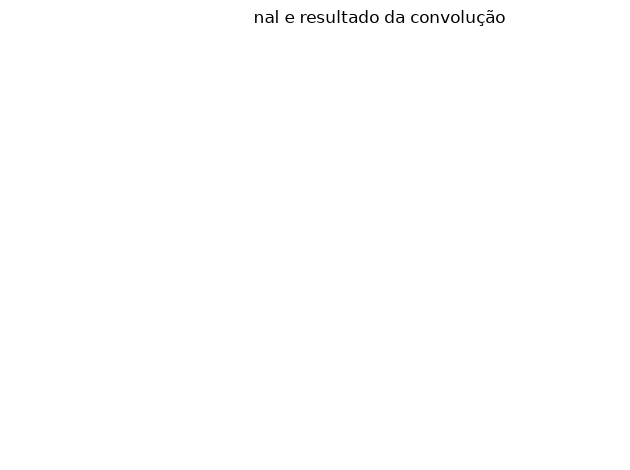

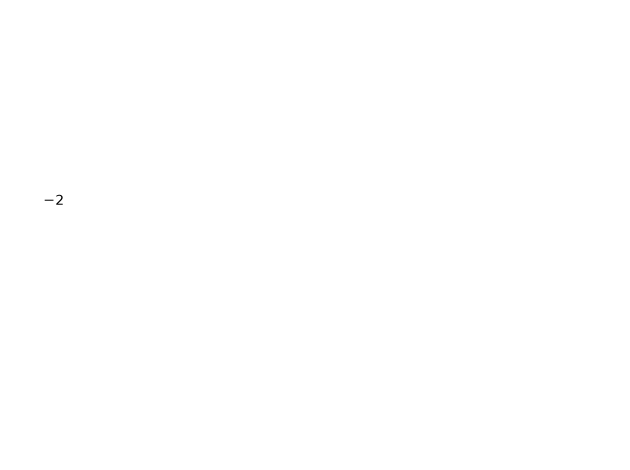


Perceba como o resultado da convolução tem picos onde o sinal muda bruscamente (de 0 para 1 ou de 1 para 0). O filtro detectou as 'bordas' do nosso sinal!


In [5]:
# Plotando os resultados
fig, ax = plt.subplots(2, 1, sharex='all', sharey='all') # , figsize=(12, 6))
ax[0].stem(sinal, linefmt='c-', markerfmt='co', basefmt='c-', label='x[n]')
ax[0].set_title('Sinal original e resultado da convolução')
ax[0].legend(loc='center right')
ax[0].grid(True)

ax[1].stem(resultado, linefmt='r-', markerfmt='ro', basefmt='r-', label='y[n]=x[n]*h[n]')
ax[1].set_xlabel('Tempo')
ax[1].legend(loc='center right')
ax[1].grid(True)

figureFormat(ax, fig, tight=True)
plt.show()

print("\nPerceba como o resultado da convolução tem picos onde o sinal muda bruscamente (de 0 para 1 ou de 1 para 0). O filtro detectou as 'bordas' do nosso sinal!")


Áudio original:


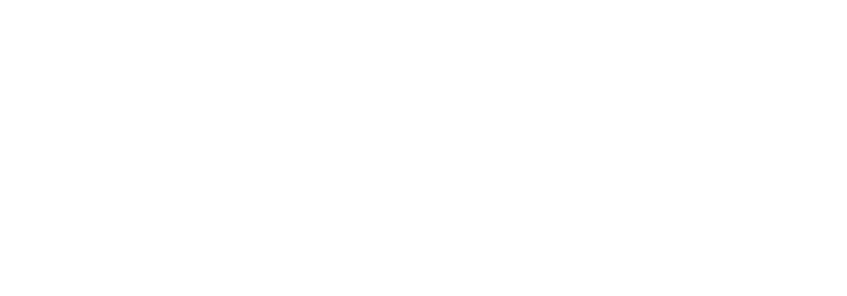

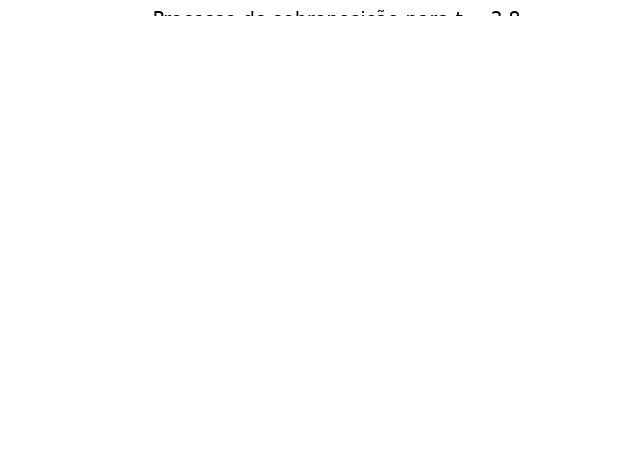


Resultado do filtro 'Passa-baixa (abafado)':


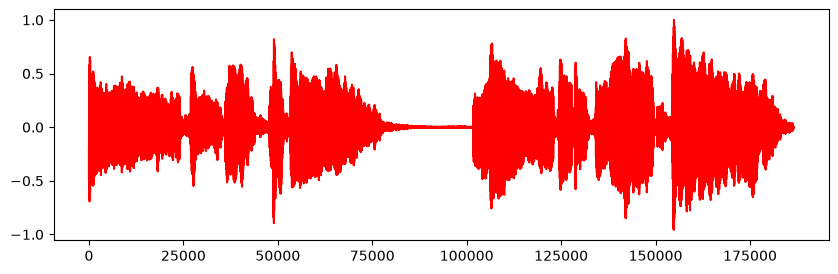

In [6]:
from scipy.io import wavfile
from IPython.display import Audio, display
import os

# --- Carregar um arquivo de áudio de exemplo (.wav) ---
nome_arquivo_audio = '../../sounds/freddy.wav'
if not os.path.exists(nome_arquivo_audio):
    print('Arquivo local não encontrado. Certifique-se de que freddy.wav está na pasta sounds.')
else:
    taxa_amostragem, audio_data = wavfile.read(nome_arquivo_audio)
    if audio_data.dtype == np.int16:
        audio_data = audio_data.astype(np.float32) / 32767.0
    elif audio_data.dtype == np.uint8:
        audio_data = (audio_data.astype(np.float32) - 128) / 128.0

    if len(audio_data.shape) > 1:
        audio_data = audio_data[:, 0]

    print("Áudio original:")
    display(Audio(audio_data, rate=taxa_amostragem))

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(audio_data, 'r')
    ax.set_title("Forma de onda do áudio original")
    plt.show()

    eco_delay_amostras = int(0.2 * taxa_amostragem)
    filtro_eco = np.zeros(eco_delay_amostras + 1)
    filtro_eco[0] = 1.0
    filtro_eco[eco_delay_amostras] = 0.6
    
    filtro_passa_baixa = np.ones(15) / 15
    filtro_passa_alta = np.array([-1.0, 2.0, -1.0])

    filtros_audio = {
        'Eco': filtro_eco,
        'Passa-baixa (abafado)': filtro_passa_baixa,
        'Passa-alta (metálico)': filtro_passa_alta
    }

    def aplicar_filtro_no_audio(nome_do_filtro):
        kernel = filtros_audio[nome_do_filtro]
        audio_convoluido = np.convolve(audio_data, kernel, mode='same')
        max_val = np.max(np.abs(audio_convoluido))
        if max_val > 0:
            audio_convoluido = audio_convoluido / max_val
        print(f"\nResultado do filtro '{nome_do_filtro}':")
        display(Audio(audio_convoluido, rate=taxa_amostragem))
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(audio_convoluido, 'r')
        plt.show()

    # Como widgets interativos falham em exports estáticos, testamos o passa-baixa diretamente:
    aplicar_filtro_no_audio('Passa-baixa (abafado)')

### 4.2 Convolução 2D: O experimento na matriz
Agora, vamos para duas dimensões. Usaremos uma matriz 10x10 com valores de 0 a 255 (como uma imagem em escala de cinza) e aplicaremos diferentes filtros para ver o que acontece.

<img src="https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExdzRoeDBqMmwwMWc0amE4Z2V5bGp3YnFsbWUyMm1peG51b3Z5cnFuNCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/i4NjAwytgIRDW/giphy.gif">


Matriz de Entrada (Pense nela como uma imagem 10x10 pixels):


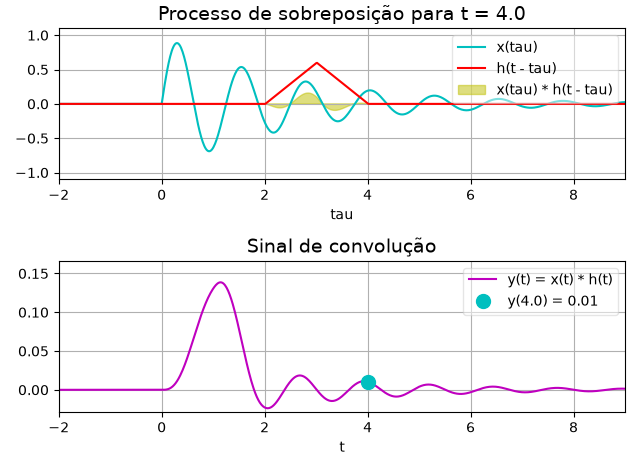

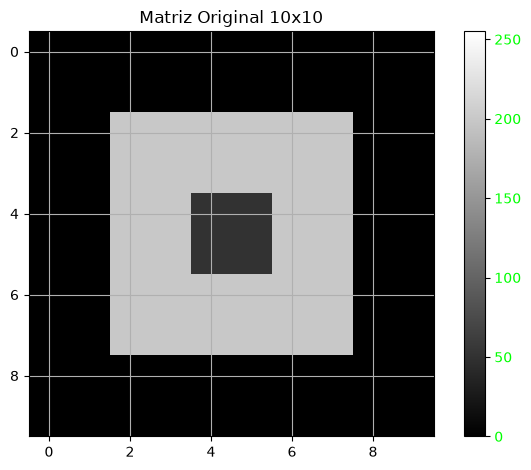

interactive(children=(Dropdown(description='nome_do_filtro', options=('Identidade', 'Detector de Bordas Vertic…

<function __main__.aplicar_e_mostrar_filtro(nome_do_filtro)>

In [7]:
from scipy.signal import convolve2d

# Criar uma matriz 10x10 interessante para o experimento
# Vamos criar uma espécie de "quadrado" no meio
matriz_base = np.zeros((10, 10), dtype=np.uint8)
matriz_base[2:8, 2:8] = 200 # Um quadrado claro no centro
matriz_base[4:6, 4:6] = 50 # Um quadrado escuro dentro do claro

print("Matriz de Entrada (Pense nela como uma imagem 10x10 pixels):")
fig, ax = plt.subplots()
ax.set_title("Matriz Original 10x10")
im = ax.imshow(matriz_base, cmap='gray', vmin=0, vmax=255)
cbar = fig.colorbar(im, ax=ax)
cb_ytick = plt.getp(cbar.ax.axes, 'yticklabels')
plt.setp(cb_ytick, color='lime')

figureFormat(ax, fig, tight=True)
plt.show()

# --- Definindo os Filtros (Kernels) ---
# Cada filtro é uma pequena matriz que extrai uma informação diferente

# 1. Filtro de Identidade: Não faz nada, o resultado é a própria imagem.
filtro_identidade = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
])

# 2. Filtro de Detecção de Bordas Verticais (Sobel)
filtro_sobel_vertical = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# 3. Filtro de Detecção de Bordas Horizontais (Sobel)
filtro_sobel_horizontal = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

# 4. Filtro de "Sharpen" (Aguçar/Realçar detalhes)
filtro_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# 5. Filtro de "Box Blur" (Borrão/Suavização)
# A soma dos elementos deve ser 1 para não alterar o brilho.
filtro_blur = (1/9) * np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

#6. Filtro Gaussiano
filtro_gaussiano = (1/16) * np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
])

# Dicionário de filtros para o dropdown
filtros_disponiveis = {
    "Identidade": filtro_identidade,
    "Detector de Bordas Verticais": filtro_sobel_vertical,
    "Detector de Bordas Horizontais": filtro_sobel_horizontal,
    "Realçar Detalhes (Sharpen)": filtro_sharpen,
    "Suavização (Blur)": filtro_blur,
    "Gaussiano": filtro_gaussiano
}

# Função que será chamada pelo widget interativo
def aplicar_e_mostrar_filtro(nome_do_filtro):
    filtro_selecionado = filtros_disponiveis[nome_do_filtro]

    # Aplicar a convolução 2D
    # O modo 'same' garante que a saída tenha o mesmo tamanho da entrada
    matriz_convoluida = convolve2d(matriz_base, filtro_selecionado, mode='same', boundary='fill', fillvalue=0)

    # Plotar os resultados lado a lado
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    # Matriz Original
    im1 = ax[0].imshow(matriz_base, cmap='gray', vmin=0, vmax=255)
    ax[0].set_title("Matriz Original")
    cbar = fig.colorbar(im1, ax=ax[0], fraction=0.046, pad=0.04)
    cb_ytick = plt.getp(cbar.ax.axes, 'yticklabels')
    plt.setp(cb_ytick, color='lime')

    # Filtro
    im2 = ax[1].imshow(filtro_selecionado, cmap='coolwarm')
    ax[1].set_title(f"Filtro: {nome_do_filtro}")
    for (j, i), label in np.ndenumerate(filtro_selecionado):
        ax[1].text(i, j, f'{label:.1f}', ha='center', va='center', color='white', fontsize=12)

    # Matriz Resultante
    im3 = ax[2].imshow(matriz_convoluida, cmap='gray')
    ax[2].set_title("Matriz Resultante da Convolução")
    cbar = fig.colorbar(im3, ax=ax[2], fraction=0.046, pad=0.04)
    cb_ytick = plt.getp(cbar.ax.axes, 'yticklabels')
    plt.setp(cb_ytick, color='lime')

    figureFormat(ax, fig, tight=True)
    plt.show()

    print("\n--- O que aconteceu? ---")
    if nome_do_filtro == "Identidade":
        print("O filtro identidade, com um '1' no centro, simplesmente copia o valor do pixel original. O resultado é idêntico à entrada.")
    elif "Bordas Verticais" in nome_do_filtro:
        print("Este filtro possui valores negativos à esquerda e positivos à direita. O resultado é alto (branco) onde há uma transição de escuro para claro na vertical, e baixo (preto) onde a transição é de claro para escuro.")
    elif "Bordas Horizontais" in nome_do_filtro:
        print("Similar ao anterior, mas na horizontal. Ele realça as bordas de cima e de baixo do nosso quadrado.")
    elif "Realçar Detalhes" in nome_do_filtro:
        print("Este filtro subtrai os valores dos vizinhos do valor central (que é multiplicado por 5). Isso aumenta a diferença entre um pixel e seus vizinhos, tornando a imagem mais 'nítida'.")
    elif "Suavização" in nome_do_filtro:
        print("Este filtro calcula a média dos valores dos pixels vizinhos. Isso suaviza as transições bruscas, criando um efeito de 'borrão' (blur).")

# Criar o widget interativo
interact(aplicar_e_mostrar_filtro, nome_do_filtro=list(filtros_disponiveis.keys()))


### 4.3 Aplicação prática: Convolução em imagens
Agora vamos sair da matriz 10x10 e aplicar os mesmos filtros em uma imagem de verdade. Para simplificar, vamos convertê-la para escala de cinza primeiro.


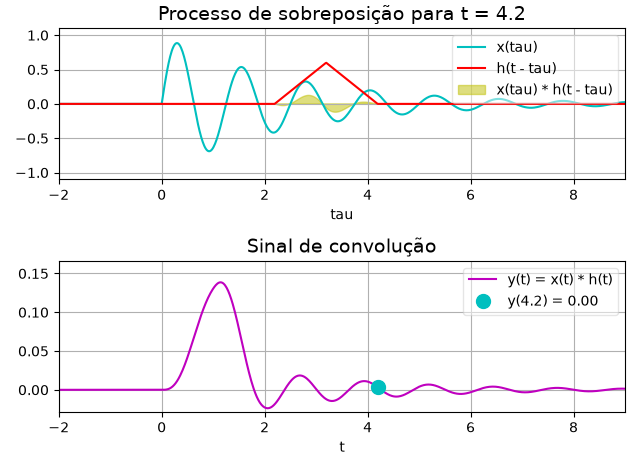

interactive(children=(Dropdown(description='Filtro:', index=1, options=('Blur (Média)', 'Detecção de Bordas (S…

In [8]:
from PIL import Image, ImageDraw
from io import BytesIO
import requests
from scipy.signal import convolve2d

url_imagem = "https://wallpapers.com/images/hd/animal-planet-blue-and-yellow-macaw-4ukd4g7gkurs6bri.jpg"

# Nome diferente de `filtros_disponiveis` (seção 4.2) para não quebrar o dropdown daquela seção
filtros_imagem = {
    'Blur (Média)': np.ones((5, 5), np.float32) / 25,
    'Detecção de Bordas (Sobel X)': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], np.float32),
    'Sharpen (Nitidez)': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], np.float32)
}

def imagem_sintetica(tamanho=300):
    '''
    Gera uma imagem em escala de cinza com formas geométricas (usada se o download falhar).
    '''
    img = Image.new('L', (tamanho, tamanho), 40)
    draw = ImageDraw.Draw(img)
    draw.rectangle([40, 40, 140, 140], fill=200)
    draw.ellipse([160, 60, 260, 160], fill=120)
    draw.polygon([(60, 260), (150, 170), (240, 260)], fill=230)
    draw.text((110, 275), 'IMAGEM', fill=255)
    return np.array(img)

try:
    response = requests.get(url_imagem, timeout=5, headers={'User-Agent': 'Mozilla/5.0'})
    response.raise_for_status()
    img_pil = Image.open(BytesIO(response.content)).convert('L')
    img_original_gray = np.array(img_pil)
except Exception as e:
    print(f"Falha ao baixar imagem ({e}). Usando imagem sintética.")
    img_original_gray = imagem_sintetica()

def aplicar_filtro_na_imagem(nome_do_filtro):
    filtro_selecionado = filtros_imagem[nome_do_filtro]
    # Convolução 2D em ponto flutuante; depois saturamos em [0, 255] e voltamos para uint8 (como uma imagem)
    imagem_filtrada = convolve2d(img_original_gray.astype(np.float32), filtro_selecionado, mode='same', boundary='symm')
    imagem_filtrada = np.clip(imagem_filtrada, 0, 255).astype(np.uint8)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(img_original_gray, cmap='gray', vmin=0, vmax=255)
    ax[0].set_title("Original")
    ax[0].axis('off')
    ax[1].imshow(imagem_filtrada, cmap='gray', vmin=0, vmax=255)
    ax[1].set_title(f"Filtro '{nome_do_filtro}'")
    ax[1].axis('off')
    plt.show()

interact(
    aplicar_filtro_na_imagem,
    nome_do_filtro=widgets.Dropdown(options=list(filtros_imagem.keys()), value='Detecção de Bordas (Sobel X)', description='Filtro:')
);

## 5. Conclusão
Hoje vimos que a **Convolução** é muito mais que uma equação complexa. É uma ferramenta poderosa e versátil para **extração de características**.

- **O Conceito Central:** Uma operação de "janela deslizante" onde um **filtro (kernel)** é aplicado sobre os dados.
- **Em 1D (Vetores/Séries Temporais/Áudio):** Vimos como a convolução pode detectar mudanças em um sinal ou criar efeitos como eco e filtros de frequência.
- **Em 2D (Matrizes/Imagens):** Vimos como diferentes filtros podem detectar bordas, suavizar (blur) ou realçar detalhes (sharpen) em uma imagem.

O que você viu aqui é a base para muitas técnicas avançadas:

-   **Visão Computacional:** As Redes Neurais Convolucionais (CNNs) usam esse princípio para aprender automaticamente os melhores filtros para reconhecer objetos, faces e cenas em imagens.
-   **Processamento de Áudio:** Equalizadores, removedores de ruído e sintetizadores de voz usam convoluções extensivamente.
-   **Análise de Sinais:** Em campos como medicina (ECG, EEG) e geofísica, a convolução é usada para filtrar ruídos e identificar padrões.

Esperamos que esta apresentação tenha tornado o conceito de convolução mais claro e prático!


### Conclusão sobre Convolução
A convolução provou ser uma operação linear fundamental operando de maneira semelhante tanto em sinais 1D (Áudio) quanto 2D (Imagens). No processamento de áudio, ela atua filtrando frequências (filtros FIR) ou criando ecos/reverbs dependendo da resposta ao impulso ($h[n]$). Em imagens, as matrizes de convolução (kernels) extraem características locais, compondo a base fundacional para operações avançadas como Redes Neurais Convolucionais (CNNs).